# Orthogonality of $\cos(mx),\cos(nx),\sin(mx),\sin(nx)$ on $[-\pi,\pi]$

We use the inner product

$$
\langle f,g\rangle = \int_{-\pi}^{\pi} f(x)g(x)\,dx
$$

For integers $m,n \ge 0$:

- $\int_{-\pi}^{\pi}\cos(mx)\cos(nx)\,dx = 0$ when $m\neq n$
- $\int_{-\pi}^{\pi}\sin(mx)\sin(nx)\,dx = 0$ when $m\neq n$
- $\int_{-\pi}^{\pi}\sin(mx)\cos(nx)\,dx = 0$ for all $m,n$

Special cases:

- $\int_{-\pi}^{\pi}\cos^2(nx)\,dx = \pi$ for $n\ge 1$, and $\int_{-\pi}^{\pi}1\,dx=2\pi$ for $n=0$
- $\int_{-\pi}^{\pi}\sin^2(nx)\,dx = \pi$ for $n\ge 1$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dense grid on [-pi, pi]
x = np.linspace(-np.pi, np.pi, 20001)


def inner_product(f_vals, g_vals, x_grid):
    return np.trapezoid(f_vals * g_vals, x_grid)


def cos_m(m, x_grid):
    return np.cos(m * x_grid)


def sin_m(m, x_grid):
    return np.sin(m * x_grid)

# Explore a finite set of frequencies
max_n = 6
modes = np.arange(0, max_n + 1)

CC = np.zeros((len(modes), len(modes)))  # <cos(mx), cos(nx)>
SS = np.zeros((len(modes), len(modes)))  # <sin(mx), sin(nx)>
SC = np.zeros((len(modes), len(modes)))  # <sin(mx), cos(nx)>

for i, m in enumerate(modes):
    for j, n in enumerate(modes):
        CC[i, j] = inner_product(cos_m(m, x), cos_m(n, x), x)
        SS[i, j] = inner_product(sin_m(m, x), sin_m(n, x), x)
        SC[i, j] = inner_product(sin_m(m, x), cos_m(n, x), x)

print('Modes:', modes)
print('\n<cos(mx), cos(nx)> ≈')
print(np.round(CC, 6))
print('\n<sin(mx), sin(nx)> ≈')
print(np.round(SS, 6))
print('\n<sin(mx), cos(nx)> ≈')
print(np.round(SC, 6))

Modes: [0 1 2 3 4 5 6]

<cos(mx), cos(nx)> ≈
[[ 6.283185  0.       -0.        0.       -0.        0.       -0.      ]
 [ 0.        3.141593  0.       -0.        0.       -0.        0.      ]
 [-0.        0.        3.141593  0.       -0.        0.       -0.      ]
 [ 0.       -0.        0.        3.141593  0.       -0.        0.      ]
 [-0.        0.       -0.        0.        3.141593  0.       -0.      ]
 [ 0.       -0.        0.       -0.        0.        3.141593  0.      ]
 [-0.        0.       -0.        0.       -0.        0.        3.141593]]

<sin(mx), sin(nx)> ≈
[[ 0.        0.        0.        0.        0.        0.        0.      ]
 [ 0.        3.141593  0.        0.        0.       -0.        0.      ]
 [ 0.        0.        3.141593  0.        0.       -0.        0.      ]
 [ 0.        0.        0.        3.141593  0.        0.       -0.      ]
 [ 0.        0.        0.        0.        3.141593  0.        0.      ]
 [ 0.       -0.       -0.        0.        0.        3.1

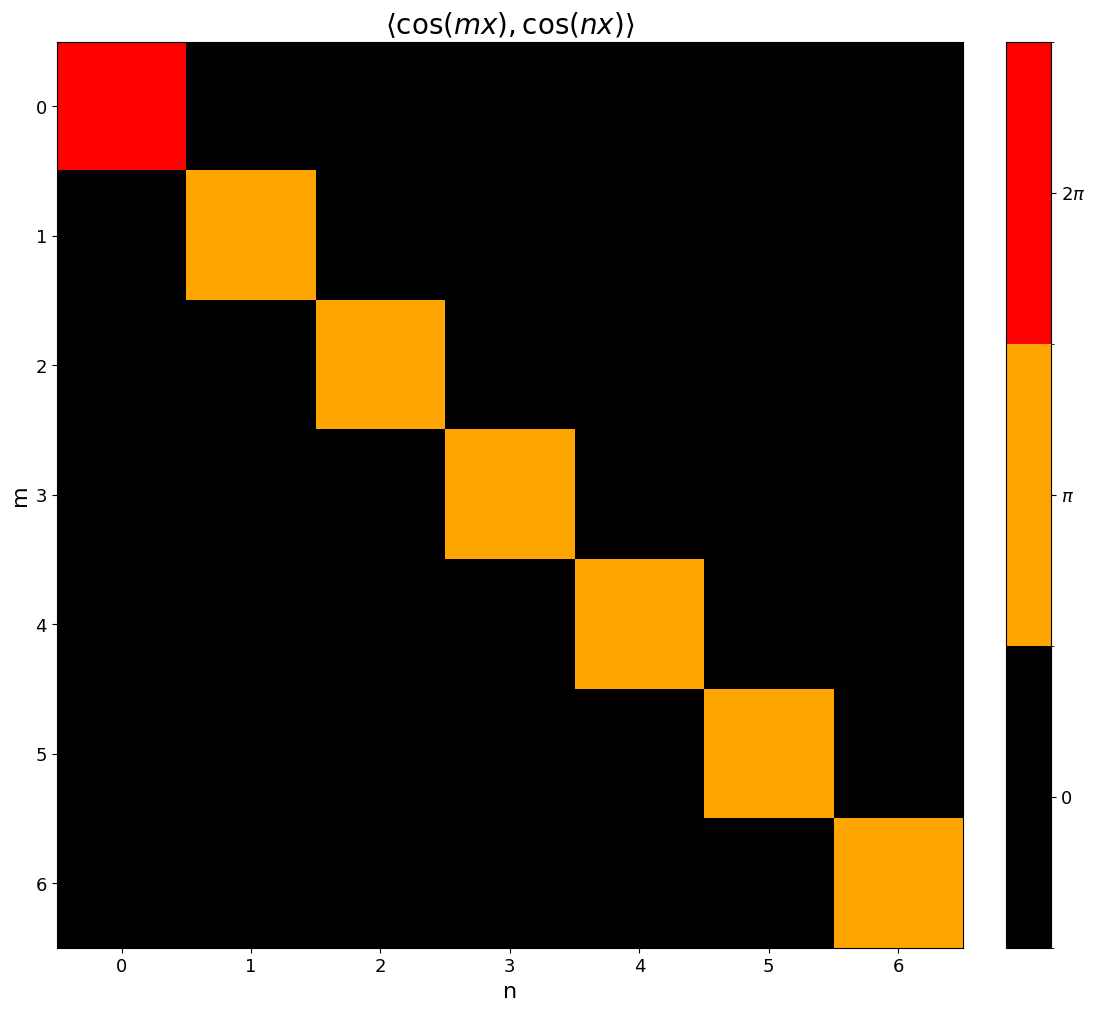

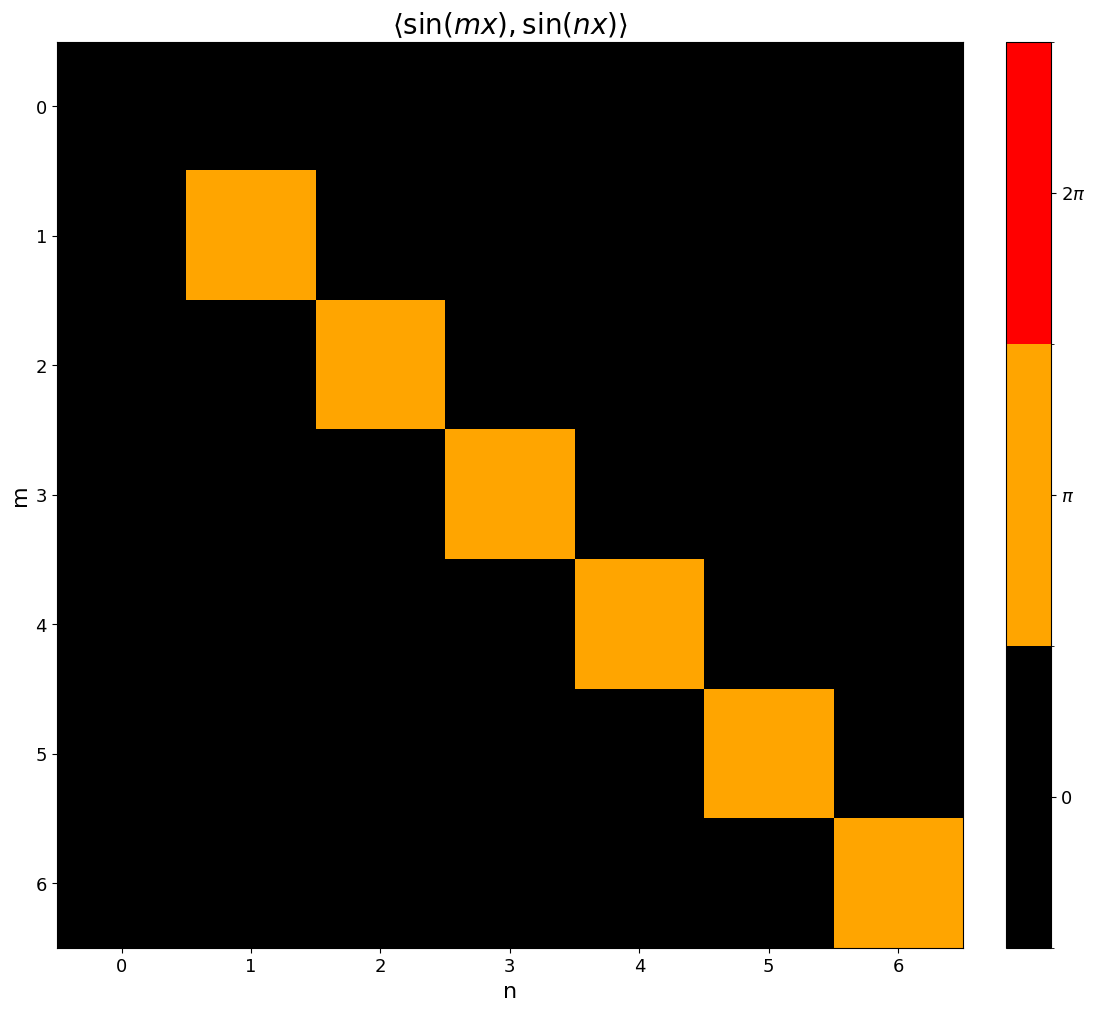

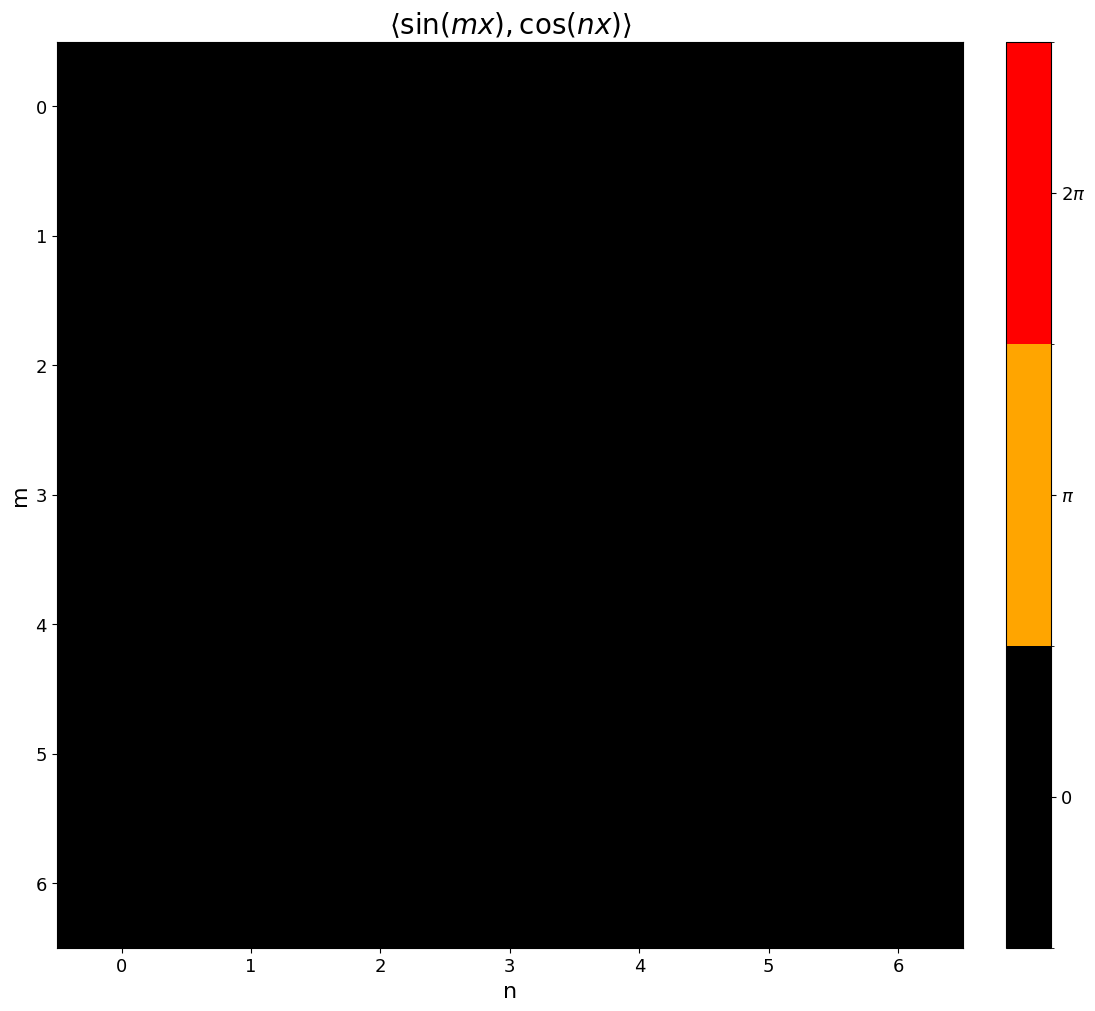

In [16]:
from matplotlib.colors import ListedColormap, BoundaryNorm


def snap_to_levels(vals, tol=1e-6):
    snapped = np.zeros_like(vals, dtype=float)
    snapped[np.isclose(vals, np.pi, atol=tol)] = np.pi
    snapped[np.isclose(vals, 2 * np.pi, atol=tol)] = 2 * np.pi
    return snapped


def encode_levels(snapped):
    encoded = np.zeros_like(snapped, dtype=int)
    encoded[np.isclose(snapped, np.pi)] = 1
    encoded[np.isclose(snapped, 2 * np.pi)] = 2
    return encoded


def plot_matrix(matrix, title):
    fig, ax = plt.subplots(figsize=(12, 10), constrained_layout=True)
    im = ax.imshow(matrix, cmap=cmap, norm=norm)
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('n', fontsize=16)
    ax.set_ylabel('m', fontsize=16)
    ax.set_xticks(range(len(modes)))
    ax.set_yticks(range(len(modes)))
    ax.tick_params(axis='both', labelsize=13)
    cb = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.046, pad=0.04)
    cb.ax.set_yticklabels(['0', r'$\pi$', r'$2\pi$'])
    cb.ax.tick_params(labelsize=13)
    plt.show()


CC_plot = encode_levels(snap_to_levels(CC))
SS_plot = encode_levels(snap_to_levels(SS))
SC_plot = encode_levels(snap_to_levels(SC))

cmap = ListedColormap(['black', 'orange', 'red'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

plot_matrix(CC_plot, r'$\langle \cos(mx),\cos(nx)\rangle$')
plot_matrix(SS_plot, r'$\langle \sin(mx),\sin(nx)\rangle$')
plot_matrix(SC_plot, r'$\langle \sin(mx),\cos(nx)\rangle$')